# <center>Project 1 2026</center>

<center>Author: Lewei Xu (23709058)</center>

In this project, we will deal with a small colour image dataset containing 10 classes, each image is 64 x 64 x 3 pixels. The training set, validation set, and test set are perfectly balanced, but only 370 training instances are available in each class. In this project, we will:

1. Train a CNN model including hyperparameter tuning. (Section 2)
2. Retrain a pretained NASNetMobile model. (Section 3)
3. Compare these 2 models. (Section 4)

### Environment, Hardware and Running the Notebook

This project was developed and run on the following setup, and the timings reported are specific to this hardware:

1. GPU: nvidia rtx 5070 12gb (blackwell 12.0)
2. CPU/RAM: Intel core ultra 7 265K, 20 cores, 64gb RAM
3. OS: Ubuntu on WSL2, NVIDIA driver 591.86
4. Software versions: Python 3.12.13, TensorFlow 2.21.0 (conda build CUDA 13.0), Keras 3.15.0

TensorFlow 2.21 was used instead of the specified 2.20 in the unit's yaml configuration due to incompatibility with rtx5070 sm_120 (TensorFlow 2.20 only works with sm_60 to sm_90). The code itself however should not be specific to hardware or environment, so as long as a compatible environment is installed, this notebook should run.

In addition, tuning/training times fluctuate slightly between runs. Included below are the times for the most recent run before submission (in seconds).

During marking, the hyperparameter tuning process of the CNN model should be skipped, but in the project spec, there is no detail on how to handle the retraining of the NASNetMobile model (if the whole notebook is run, the NASNetMobile training will run and the new model will overwrite the current one on disk). As such, included below are 2 boolean variables to control whether the 2 training blocks will be run. `hyperparameter_tuning` has been set to `False` as per the project spec, so the Bayesian optimisation search is bypassed and the CNN is model is loaded from disk. `NASNetMobile_training` however has been set to `True` as the project spec does not specify to skip the NASNetMobile training. In the current configuration, hyperparameter tuning will be skipped, while the NASNetMobile training will run to produce the learning curve.

In [ ]:
hyperparameter_tuning = False
NASNetMobile_training = True

tuning_time = 2887
nasnet_time = 88

## Section 1: Setup and Preprocessing

### Section 1.1: Imports and Data Loading

First, we will make the required imports and set configurations that will be used throughout the project.

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from IPython.display import display
from pathlib import Path
import time
import json

np.random.seed(42)
tf.random.set_seed(42)

CNN_FILE = "Xu_Lewei-CNN.keras"
NASNET_FILE = "Xu_Lewei-NASNetMobile.keras"
PROJECT_NAME = "project1"
TUNING_DIR = Path("cnn_tuning") / PROJECT_NAME

I0000 00:00:1788415456.418072   96194 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788415456.578120   96194 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


The 3 .pkl files store their contents using byte string keys. We will load them using the code provided by the project spec, and verify the shapes.

In [4]:
def load_data(pickle_file):
    import pickle
    with open(pickle_file, "rb") as f:
        dict = pickle.load(f)
    return dict[b"data"], dict[b"labels"], dict[b"class_names"]

X_train, y_train, class_names = load_data("./train-2026.pkl")
X_valid, y_valid, _ = load_data("./valid-2026.pkl")
X_test, y_test, _ = load_data("./test-2026.pkl")

# Check the shapes of the datasets and the data type and range of the training data
print(f"train: {X_train.shape} {y_train.shape}")
print(f"valid: {X_valid.shape} {y_valid.shape}")
print(f"test: {X_test.shape} {y_test.shape}")
print(f"dtype: {X_train.dtype} range: {X_train.min()} {X_train.max()}")

train: (3700, 64, 64, 3) (3700,)
valid: (800, 64, 64, 3) (800,)
test: (500, 64, 64, 3) (500,)
dtype: uint8 range: 0 255


In [5]:
n_classes = len(class_names)
pd.DataFrame({
    "train": np.bincount(y_train, minlength=n_classes),
    "valid": np.bincount(y_valid, minlength=n_classes),
    "test": np.bincount(y_test, minlength=n_classes),
}, index=class_names)

,train,valid,test
alligator,370,80,50
dragonfly,370,80,50
dugong,370,80,50
goldfish,370,80,50
goose,370,80,50
koala,370,80,50
scorpion,370,80,50
slug,370,80,50
snail,370,80,50
tarantula,370,80,50


Here we can see that the training set consists of 370 training instances per class across 10 classes, as specified by the project spec.

### Section 1.2: Data Exploration

We will now write a function ``display_images`` that samples images at random. The optional `indices` amd `y_pred` arguments allow us to reuse it for the Comparisons section of our CNN models later on.

In [6]:
def display_images(X, y, class_names, title, n_images=30, n_cols=10, indices=None, y_pred=None, seed=42):

    # Get random indices if not provided
    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(len(X), size=min(n_images, len(X)), replace=False)
    indices = np.asarray(indices)[:n_images]

    # Display images
    n_rows = int(np.ceil(len(indices) / n_cols))
    plt.figure(figsize=(n_cols * 1.4, n_rows * 1.8))
    for i, index in enumerate(indices):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X[index])
        plt.axis("off")

        # Display true label and predicted label if provided (for comparisons section)
        if y_pred is None:
            plt.title(class_names[y[index]], fontsize=9)
        else:
            plt.title(f"{class_names[y[index]]} -> {class_names[y_pred[index]]}", fontsize=8)
    plt.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.show()

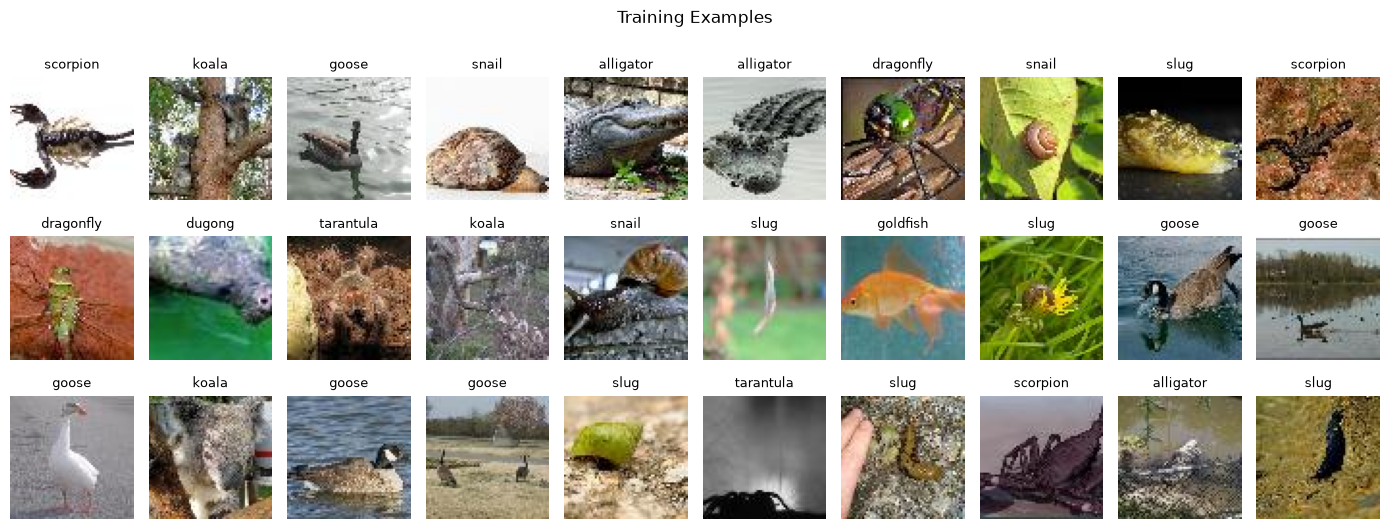

In [7]:
display_images(X_train, y_train, class_names, title="Training Examples")

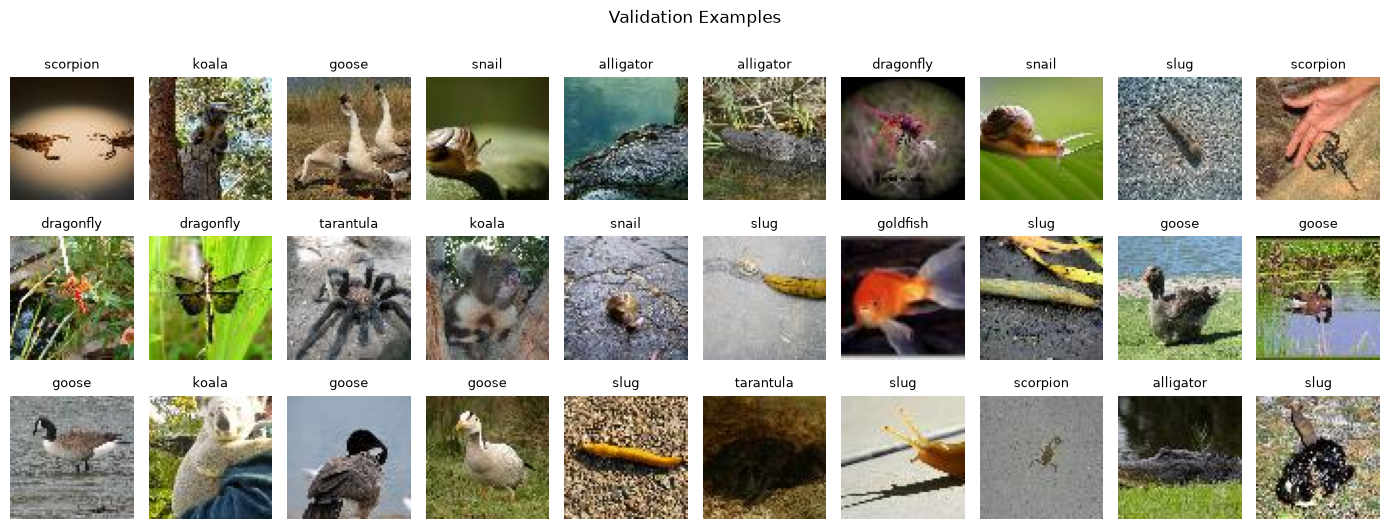

In [8]:
display_images(X_valid, y_valid, class_names, title="Validation Examples")

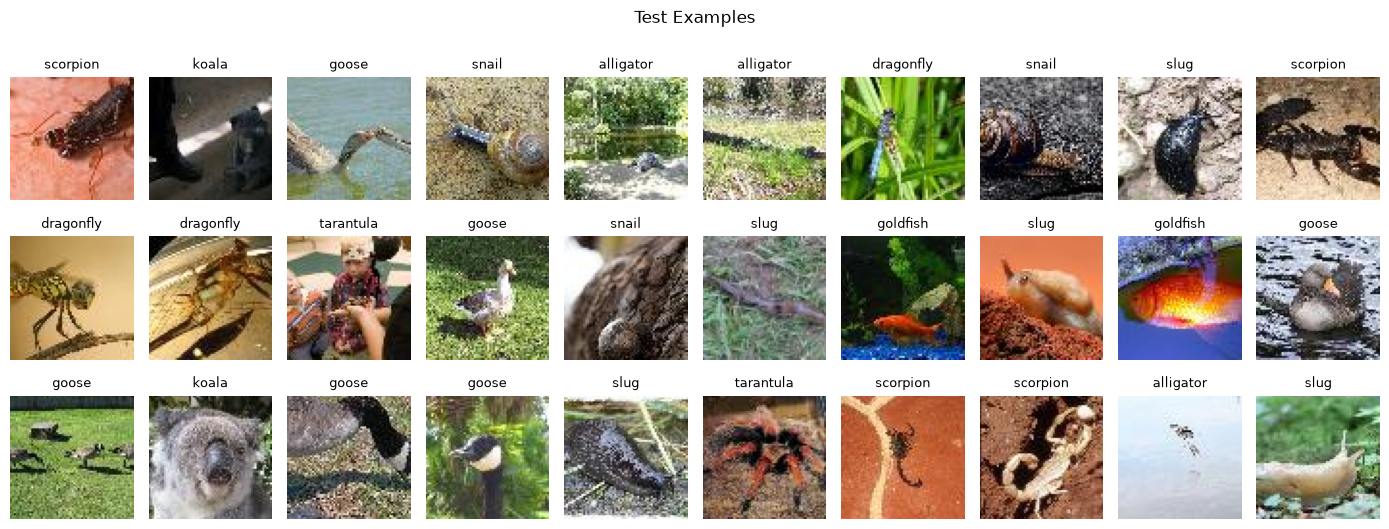

In [9]:
display_images(X_test, y_test, class_names, title="Test Examples")

Here we can see that the images are small and quite varied. Animals appear at different sizes within the image and vary in orientation, with various backgrounds within the same class. Colour pallettes between different classes also overlap, making this a very had problem.

### Section 1.3: Preprocessing

Training instances are stored in increasing classID order, so we must shuffle the training set before it is used, otherwise the mini batches would each contain mostly a single class causing the training to be unstable.

No need to scale the pixel range as this will be done in each model's ``Rescaling`` layer. This additionally allows the models to handle raw images at prediction time.

In [10]:
print("First 20 training labels before shuffling:", y_train[:20])

rng = np.random.default_rng(42)

train_order = rng.permutation(len(X_train))
X_train, y_train = X_train[train_order], y_train[train_order]

print("First 20 training labels after shuffling:", y_train[:20])

First 20 training labels before shuffling: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
First 20 training labels after shuffling: [8 4 6 6 5 6 1 8 5 1 2 2 7 3 3 6 8 7 7 7]


## Section 2: CNN Model and Hyperparameter Tuning

Now that all our setup and preprocessing is done, we will now design and train a CNN model for this animal classification task.

### Section 2.1: Design CNN Model with Hyperparameter Tuning

First, we will define our CNN model design with hyperparameter tuning. The networks consists of (in the following order):
1. A 64 x 64 x 3 input layer
2. A Rescaling layer to scale inputs between 0-1
3. 4 convolutional layers, with 4 pooling layers after each convolutional layer
4. A global average pooling layer before the parameter heavy dense layer
5. A dropout layer
6. A single dense layer
7. Finally, a 10 way softmax output layer

In addition, we will insert 2 augmentation layers, a random horizontal flipping layer and a random rotation layer, before the convolution layers to assist with training and possibly increase performance. This allows us to artificially increase the size of the training set which is currently somewhat small, and apply some regularization to the model and make it more tolerant to variations in position and orientation.

The ranges of the 6 tuned hyperparameters have been chosen so that every combination of the search space stays under 30 000 trainable parameters, with the worst case being 28 354 parameters.

We will use ReLU activations for all layers with He initialization as required, with Nadam optimizer.

In [11]:
def build_cnn_model(hp):
    # Hyperparameter choices for the CNN model
    # In the worst case, the parameter count will still stay under 30 000 parameters (28 354 params)
    filters1 = hp.Choice("filters1", [8, 12, 16])
    filters2 = hp.Choice("filters2", [16, 24, 32])
    filters3 = hp.Choice("filters3", [24, 32])
    filters4 = hp.Choice("filters4", [32, 40])
    dropout_rate = hp.Float("dropout_rate", 0.2, 0.5, step=0.1)
    n_units = hp.Choice("n_units", [16, 32, 48])

    tf.random.set_seed(42) # Set seed again for reproducibility

    # Define the CNN model architecture
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=[64, 64, 3]),
        tf.keras.layers.Rescaling(1. / 255),

        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),

        tf.keras.layers.Conv2D(filters1, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters2, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters3, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters4, 3, padding="same", activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_units, activation="relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])

    # Build model 
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                  metrics=["accuracy"])
    return model

### Section 2.2: Learning Rate Scheduler

Now that we have our CNN model architecture, we need to additionally choose a suitable learning rate scheduler. We will use the exponential decay scheduler which drops the learning rate by a factor of 10 every 50 epochs. Early stopping is also be used with ``restore_best_weights=True``.

In [12]:
# Exponential decay function (copied from chapter 11)
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

def build_callbacks(lr0=1e-3, s=50, patience=20):
    lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay(lr0, s))
    early_stopping = tf.keras.callbacks.EarlyStopping(patience=patience,
                                                      restore_best_weights=True)
    return [lr_scheduler, early_stopping]

### Section 2.3: Run the Hyperparameter Search

With everything set up, we can now run the hyperparameter search. We will use the ``hyperpameter_tuning`` variable to switch between running the Bayesian optimisation search and loading the model already saved on disk. ``max_trials`` is set to 15, and in each trial, the tuner will train for 120 epochs with early stopping using the validation set as defined above. Tuning time is recorded directly using ``time.time()`` as the tuner does not return the tuning time.

In [13]:
# Perform hyperparameter tuning if specified, otherwise load the best model from file

if hyperparameter_tuning is True:
    tuner = kt.BayesianOptimization(build_cnn_model, objective="val_accuracy", max_trials=15, seed=42, overwrite=True, directory=TUNING_DIR, project_name=PROJECT_NAME)

    start_time = time.time() # Start measuring the tuning time
    tuner.search(X_train, y_train, epochs=120,
                 validation_data=(X_valid, y_valid),
                 callbacks=build_callbacks(), verbose=0)
    tuning_time = time.time() - start_time

    # Save best model
    model_cnn = tuner.get_best_models(num_models=1)[0]
    model_cnn.save(CNN_FILE)
    print(f"Tuning time: {tuning_time:.0f} s")
else:
    model_cnn = tf.keras.models.load_model(CNN_FILE)

model_cnn.summary()

I0903 14:04:22.413106   96194 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9216 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:02:00.0, compute capability: 12.0a
/home/lingwei/miniconda3/envs/tf-2.20-gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 27 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,393 (271.07 KB)

 Trainable params: 23,130 (90.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,263 (180.72 KB)

Note: this notebook was rerun with `hyperparameter_tuning = False` for final testing. The above cell outputs the logging from loading the model instead of the tuning logs. This is resolved in the following cell, where we read the tuning data from disk. Rerunning this notebook without the tuning results on disk will output nothing for the next cell, however, the results are already recorded in the following markdown cell.

In [14]:
# Display results of hyperparameter tuning or display best model architecture summary

# Read tuning results from disk directly if it exists instead of outputting model summary
if hyperparameter_tuning is True or TUNING_DIR.exists():
    rows = []
    for trial_file in sorted(TUNING_DIR.glob("trial_*/trial.json")):
        trial = json.loads(trial_file.read_text())
        if trial.get("score") is None:
            continue  # skip incomplete or failed trials

        values = trial["hyperparameters"]["values"]
        metrics = trial["metrics"]["metrics"]

        hp = kt.HyperParameters()
        hp.values.update(values)  # rebuild the model to count its parameters

        rows.append({
            "trial": trial["trial_id"],
            **values,
            "params": build_cnn_model(hp).count_params(),
            "best epoch": trial["best_step"],
            "train acc": metrics["accuracy"]["observations"][0]["value"][0],
            "val acc": metrics["val_accuracy"]["observations"][0]["value"][0],
        })

    trial_results = pd.DataFrame(rows).set_index("trial")
    display(trial_results.sort_values("val acc", ascending=False).round(4))
else:
    print("Hyperparameter tuning was skipped. Load the best model from file.")

,filters1,filters2,filters3,filters4,dropout_rate,n_units,params,best epoch,train acc,val acc
trial,,,,,,,,,,
10,8,32,32,32,0.4,48,23130,91,0.5297,0.5437
08,8,32,32,40,0.4,16,24194,63,0.5278,0.5412
12,12,16,32,40,0.3,16,19106,61,0.5335,0.5400
05,16,16,24,40,0.2,32,16570,87,0.5689,0.5375
06,8,16,24,40,0.3,48,16010,112,0.5408,0.5337
04,8,16,32,32,0.3,48,17354,102,0.5192,0.5238
03,8,16,32,40,0.4,16,18418,70,0.5127,0.5200
11,12,16,32,32,0.4,48,18042,111,0.5062,0.5200
14,8,16,32,40,0.3,48,20050,39,0.5141,0.5163


The best trial of the 15 was trial 10, achieving 54.37% validation accuracy, with:

1. filters1 = 8
2. filters2 = 32
3. filtesr3 = 32
4. filters4 = 32
5. dropout_rate = 0.4
6. n_units = 48

The next two trials reached 54.12% and 54.00%, indicating the top of the search space is fairly flat rather than a single configuration massively beating the others. The best model widens quickly (8 -> 32 filters) and stays wide, and a relatively high dropout rate was chosen, which makes sense for a small dataset.

The tuning time took 2887 seconds (~48 mins) on an RTX 5070.

### Section 2.4: Parameter Count and CNN Performance

Finally, we will check the parameter count explicitly, and check the performance of the tuned CNN on the test set.

In [15]:
cnn_trainable = int(sum(np.prod(w.shape) for w in model_cnn.trainable_weights))
print(f"CNN trainable parameters: {cnn_trainable:,}")

CNN trainable parameters: 23,130


In [16]:
cnn_valid_acc = model_cnn.evaluate(X_valid, y_valid, verbose=0)[1]
cnn_test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)[1]

print(f"CNN validation accuracy: {cnn_valid_acc:.4f}")
print(f"CNN test accuracy: {cnn_test_acc:.4f}")

I0903 14:04:24.179359   96780 cuda_dnn.cc:461] Loaded cuDNN version 92301


CNN validation accuracy: 0.5437
CNN test accuracy: 0.5500


Here, we can see that the parameter count falls well under the 30 000 limit, and we achieve 0.55 test accuracy, which is above the 0.5 accuracy requirement for this project.

## Section 3: Retraining a NASNetMobile Model

### Section 3.1: Building the Model

NASNetMobile is a reasonably small pretrained model among those available in the ``tf.keras.applications`` package, and like other models, it was trained on 224x224 ImageNet images with 1000 output classes. First, a ``Resizing`` layer is required to scale the 64 x 46 inputs up before they reach the pretrained model to avoid wasting the pretrained features even though the base network can be loaded at 64 x 64. Its ``preprocess_input`` maps pixels to the [-1, 1] required for the pretrained model, which we will use directly. 

Source: https://www.tensorflow.org/api_docs/python/tf/keras/applications/NASNetMobile

We will remove the 1000 way softmax output, and instead replace the frozen base with a global average pooling 2d layer followed by a dense layer of 80 neurons and a 10 way softmax output layer.

In [17]:

base_model = tf.keras.applications.NASNetMobile(weights="imagenet", include_top=False, input_shape=[224, 224, 3])
base_model.trainable = False # freeze every layer of the base network

tf.keras.utils.set_random_seed(42) # Set seed again for reproducibility

# Using Keras functional API to build the NASNetMobile model with a custom head
inputs = tf.keras.layers.Input(shape=[64, 64, 3])
x = tf.keras.layers.Resizing(224, 224)(inputs) # Resize input to avoid wasting pretrained features
x = tf.keras.applications.nasnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(80, activation="relu", kernel_initializer="he_normal")(x)
outputs = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
model_nasnet = tf.keras.Model(inputs=inputs, outputs=outputs)

model_nasnet.compile(loss="sparse_categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                     metrics=["accuracy"])

Next, let's inspect the first five and last four layers of the network to make sure everything is in order. As the base network is nested inside the model as a single layer, the first 5 layers of the network must be taken from inside the base model and the last four from the outer model (which are added layers) for this to be possible.

In [18]:
def summarise_layers(layers):
    return pd.DataFrame([{
        "layer": layer.name,
        "type": type(layer).__name__,
        "output shape": str(layer.output.shape),
        "params": layer.count_params(),
        "trainable": layer.trainable,
    } for layer in layers])


summarise_layers(base_model.layers[:5])

,layer,type,output shape,params,trainable
0,input_layer_15,InputLayer,"(None, 224, 224, 3)",0,False
1,stem_conv1,Conv2D,"(None, 111, 111, 32)",864,False
2,stem_bn1,BatchNormalization,"(None, 111, 111, 32)",128,False
3,activation,Activation,"(None, 111, 111, 32)",0,False
4,reduction_conv_1_stem_1,Conv2D,"(None, 111, 111, 11)",352,False


In [19]:
summarise_layers(model_nasnet.layers[-4:])

,layer,type,output shape,params,trainable
0,nasnet_mobile,Functional,"(None, 7, 7, 1056)",4269716,False
1,global_average_pooling2d_15,GlobalAveragePooling2D,"(None, 1056)",0,True
2,dense_30,Dense,"(None, 80)",84560,True
3,dense_31,Dense,"(None, 10)",810,True


### Section 3.2: Training the Added Layers

We will now train only the added layers. The base model layers are already frozen from before, and we will use the same exponential decay schedule and early stopping as the CNN from Section 2. We will turn off verbose output and only display the learning curves in a plot. Similarly, we will record the training time using ``time.time()`` for comparison.

In [20]:
if NASNetMobile_training is True:
    start_time = time.time()
    history_nasnet = model_nasnet.fit(X_train, y_train, epochs=120,
                                    validation_data=(X_valid, y_valid),
                                    callbacks=build_callbacks(), verbose=0)
    nasnet_time = time.time() - start_time

    # EarlyStopping restore_best_weights woulud have rolled the model back to the epoch with the lowest validation loss
    history = history_nasnet.history
    best_epoch = int(np.argmin(history["val_loss"]))
else:
    model_nasnet = tf.keras.models.load_model(NASNET_FILE)

I0903 14:04:35.068808   96782 service.cc:153] XLA service 0x73d9000457f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0903 14:04:35.068833   96782 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.23.1)
I0903 14:04:35.329816   96782 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0903 14:04:37.490931   96782 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38529__.832
I0903 14:04:38.856716   97076 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads

I0903 14:04:45.206149   97078 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads

I0903 

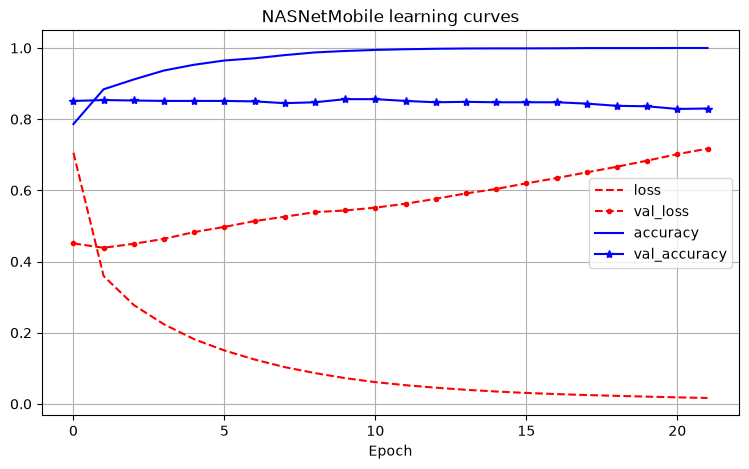

epochs actually run: 22
training time: 88 s
best epoch (weights restored from here): 2
  training loss: 0.3593
  validation loss: 0.4387
  training accuracy: 0.8841
  validation accuracy: 0.8537


In [21]:
# Plot learning curves

pd.DataFrame(history_nasnet.history)[["loss", "val_loss", "accuracy", "val_accuracy"]].plot(
    figsize=(9, 5), grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"],
    title="NASNetMobile learning curves")
plt.show()

print(f"epochs actually run: {len(history['loss'])}")
print(f"training time: {nasnet_time:.0f} s")
print(f"best epoch (weights restored from here): {best_epoch + 1}")
print(f"  training loss: {history['loss'][best_epoch]:.4f}")
print(f"  validation loss: {history['val_loss'][best_epoch]:.4f}")
print(f"  training accuracy: {history['accuracy'][best_epoch]:.4f}")
print(f"  validation accuracy: {history['val_accuracy'][best_epoch]:.4f}")

The learning curves show mild overfitting, which can be seen in the validation loss drifting up while the training loss falls as the number of epochs go by. The training accuracy ends around 88% against 85% for validation accuracy. The validation accuracy line remains largely flat while the training accuracy continues to rise to 1.0.

Let's now save the model and take a look at the NASNetMobile's overall performance.

In [22]:
if NASNetMobile_training is True:
    model_nasnet.save(NASNET_FILE)

nasnet_valid_acc = model_nasnet.evaluate(X_valid, y_valid, verbose=0)[1]
nasnet_test_acc = model_nasnet.evaluate(X_test, y_test, verbose=0)[1]

print(f"NASNetMobile validation accuracy: {nasnet_valid_acc:.4f}")
print(f"NASNetMobile test accuracy: {nasnet_test_acc:.4f}")

I0903 14:06:03.190822   96779 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



NASNetMobile validation accuracy: 0.8537
NASNetMobile test accuracy: 0.8620


I0903 14:06:07.145439   96779 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



## Section 4: Comparisons

In this section we reload both saved models and compare them directly. We compare their complexity, per-class and overall performance on the test set, confusion matrices, and the specific test images where the two models agree and disagree.

### Section 4.1: Load Models and Preliminary Report

First, to make this project rerunnable, we need to load model weights from disk.

In [23]:
# Load the models regardless of hyperparameter_tuning and NASNetMobile_training flags so this section can run independently

model_cnn = tf.keras.models.load_model(CNN_FILE)
model_nasnet = tf.keras.models.load_model(NASNET_FILE)

y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_pred_nasnet = np.argmax(model_nasnet.predict(X_test, verbose=0), axis=1)

/home/lingwei/miniconda3/envs/tf-2.20-gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 27 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0903 14:06:19.974763   96779 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads

I0903 14:06:25.745620   96778 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



In [24]:
print(f"CNN test accuracy: {accuracy_score(y_test, y_pred_cnn):.4f}")
print(f"NASNetMobile test accuracy: {accuracy_score(y_test, y_pred_nasnet):.4f}")

print(f"CNN tuning time: {tuning_time:.0f} s")
print(f"NASNetMobile training time: {nasnet_time:.0f} s")

CNN test accuracy: 0.5500
NASNetMobile test accuracy: 0.8620
CNN tuning time: 2887 s
NASNetMobile training time: 88 s


CNN hyperparameter tuning (15 trials @ up to 120 epochs): 2887 s (~48 mins)
NASNetMobile training (22 epochs early stopping): 88 s (~1.5 mins)

The CNN hyperparameter tuning (which automatically gives us the parameter weights for the best model) took ~32 times longer than the NASNetMobile fine tuning. This comparison however is not entirely valid, as hyperparameter tuning covers 15 separate models up to 120 epochs, while NASNetMobile was trained only once to 22 epochs (albeit with ~3.5x more parameters).

The pretrained model is both cheaper to train and performs signifiantly better (0.86 vs 0.55 accuracy), however, the hyperparameter tuning for NASNetMobile would still have been done by someone else using their computing resources, so overall, the NASNetMobile fine tuned model isn't necessarily cheaper. But again, this is one of the advanges of transfer learning, where a pretrained model can be adapted to various tasks, not just this image classification task.

### Section 4.2: Model Complexity

Here we count the number of trainable parameters in each model. For the NASNetMobile model the frozen base layers are excluded from the count, as only the added layers were trained.

In [25]:
def count_trainable(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))

def count_all(model):
    return int(model.count_params())

pd.DataFrame([
    {"model": "CNN", "trainable params": count_trainable(model_cnn),
     "total params": count_all(model_cnn)},
    {"model": "NASNetMobile", "trainable params": count_trainable(model_nasnet),
     "total params": count_all(model_nasnet)},
]).set_index("model")

,trainable params,total params
model,,
CNN,23130,23130
NASNetMobile,85370,4355086


NASNetMobile has ~3.5 times as many trainable parameters as the CNN, but with the ImageNet backbone included, its total parameters exceed 4.3 million, almost 200x the CNN's total.

### Section 4.3: Per-Class Precision, Recall and F1

Here we report the precision, recall and F1 score of both models for each of the 10 classes on the test set.

In [26]:
metrics = ["precision", "recall", "f1-score"]
rows = class_names + ["Overall"]

def model_report(y_pred):
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    report["Overall"] = report["weighted avg"]
    return pd.DataFrame(report).T.loc[rows, metrics]

comparison = pd.concat({"CNN": model_report(y_pred_cnn), "NASNetMobile": model_report(y_pred_nasnet)}, axis=1)
comparison.round(3)

CNN                 NASNetMobile                
          precision recall f1-score    precision recall f1-score
alligator     0.363   0.74    0.487        0.765  0.780    0.772
dragonfly     0.574   0.62    0.596        0.790  0.980    0.875
dugong        0.932   0.82    0.872        0.961  0.980    0.970
goldfish      0.909   0.80    0.851        0.979  0.920    0.948
goose         0.395   0.64    0.489        0.977  0.860    0.915
koala         0.740   0.74    0.740        0.961  0.980    0.970
scorpion      0.462   0.36    0.404        0.863  0.880    0.871
slug          0.400   0.16    0.229        0.727  0.800    0.762
snail         0.320   0.16    0.213        0.909  0.600    0.723
tarantula     0.561   0.46    0.505        0.764  0.840    0.800
Overall       0.566   0.55    0.539        0.870  0.862    0.861

Here, we can see that NASNetMobile outperforms the CNN on every class, but this margin is not the same everywhere. On classes like dugong and goldfish, the CNN falls below NASNetMobile by less than 0.1 F1, but on classes like scorpion, slug and snail, the F1 gap is much wider at 0.4-0.5. The CNN's alligator score also has a very high precision-recall imbalance at 0.74 recall vs only 0.363 precision, suggesting the model prefers to answer "alligator" as a default guess.

### Section 4.4: Confusion Matrices

Here we show the confusion matrices which show which classes each model confuses with which, rather than only how often it is wrong.

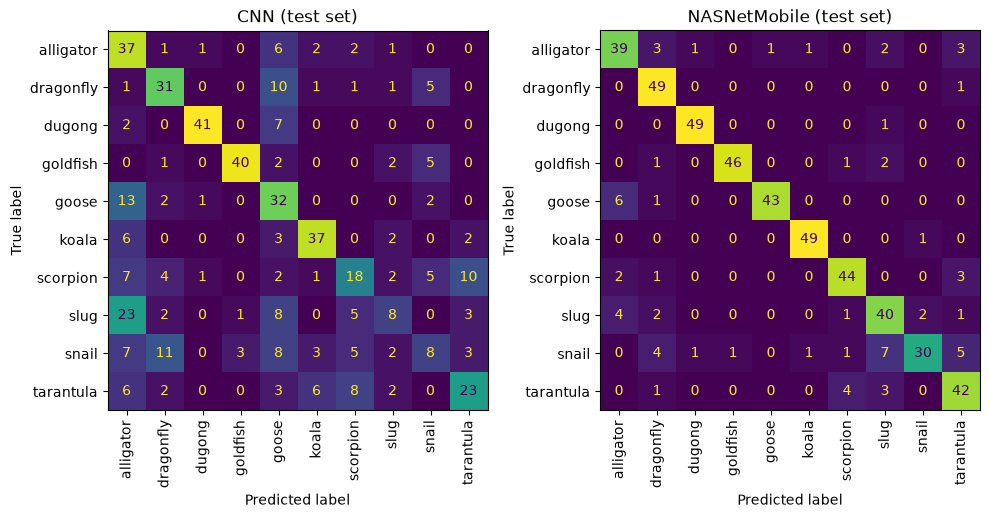

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, y_pred, name in [(axes[0], y_pred_cnn, "CNN"), (axes[1], y_pred_nasnet, "NASNetMobile")]:
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names, ax=ax, colorbar=False, xticks_rotation="vertical")
    ax.set_title(f"{name} (test set)")
plt.tight_layout()
plt.show()

The confusion matrices confirm the pattern we see above. The CNN's alligator column contains a large share of miscalssified slug and goose images, reflecting the low precision on that class. The slug/snail/dragonfly classes show heavy cross confusion with each other and with alligator class. NASNetMobile's matrix in contrast sits much closer to the diagonoal, with very few misclassifications. Its main confusion also falls on the slug/snail pair, which we can se are the hardest for both models in 4.3.

### Section 4.5: Model Comparison on Instances

Here, we will compare the two models on instances where they were both correct, both incorrect, CNN correct but NASNetMobile incorrect and NasNetMobile correct but CNN incorrect.

We will reuse the `display_images()` function from earlier by passing in the `indices` of the instances we ant to see, and the `y_pred` value of the model that got the prediction incorrect (true label -> prediction). For comparing where both models predicted wrong, we display the CNN model's incorrect prediction for simplicity.

In [28]:
cnn_correct = y_pred_cnn == y_test
nasnet_correct = y_pred_nasnet == y_test

# Find the indices of the test images that fall into each of the four groups based
groups = {
    "both correct": np.where(cnn_correct & nasnet_correct)[0],
    "both incorrect": np.where(~cnn_correct & ~nasnet_correct)[0],
    "CNN correct, NASNetMobile incorrect": np.where(cnn_correct & ~nasnet_correct)[0],
    "NASNetMobile correct, CNN incorrect": np.where(~cnn_correct & nasnet_correct)[0],
}

# Compile into dataframe to pass to display_images()
pd.DataFrame([{"group": name, "number of test images": len(idx)} for name, idx in groups.items()]).set_index("group")

,number of test images
group,
both correct,253
both incorrect,47
"CNN correct, NASNetMobile incorrect",22
"NASNetMobile correct, CNN incorrect",178


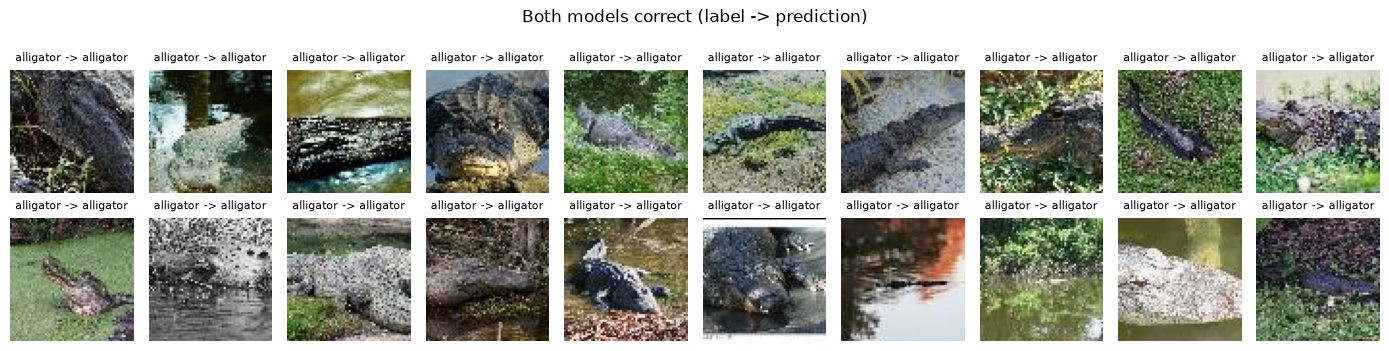

In [29]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["both correct"], y_pred=y_pred_cnn,
               title="Both models correct (label -> prediction)")

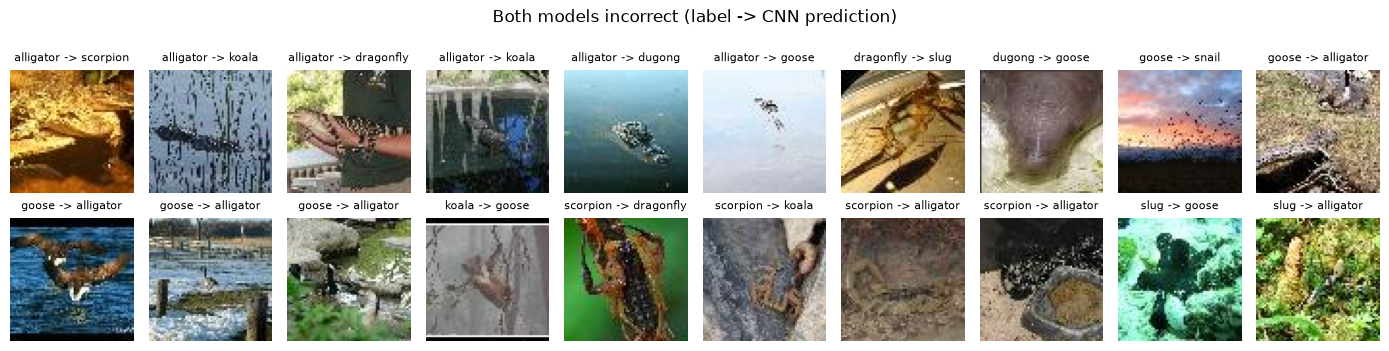

In [30]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["both incorrect"], y_pred=y_pred_cnn,
               title="Both models incorrect (label -> CNN prediction)")

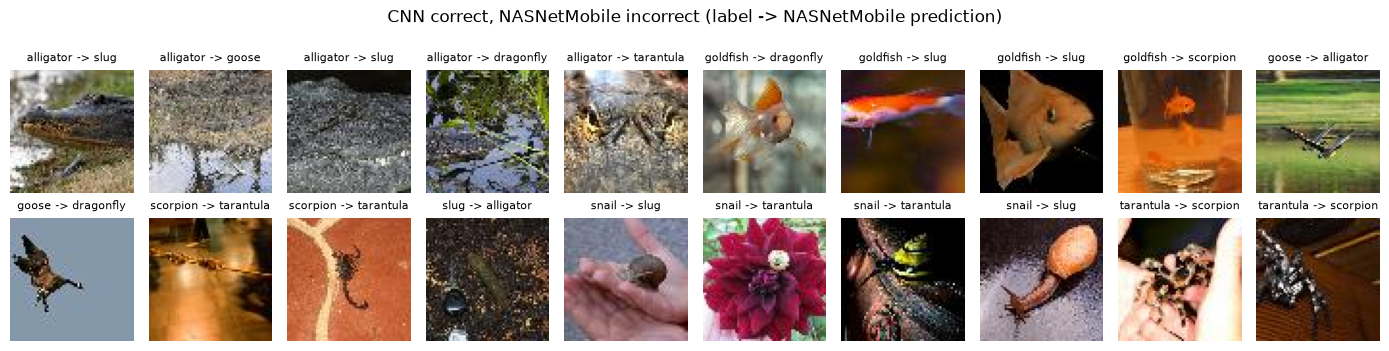

In [31]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["CNN correct, NASNetMobile incorrect"],
               y_pred=y_pred_nasnet,
               title="CNN correct, NASNetMobile incorrect (label -> NASNetMobile prediction)")

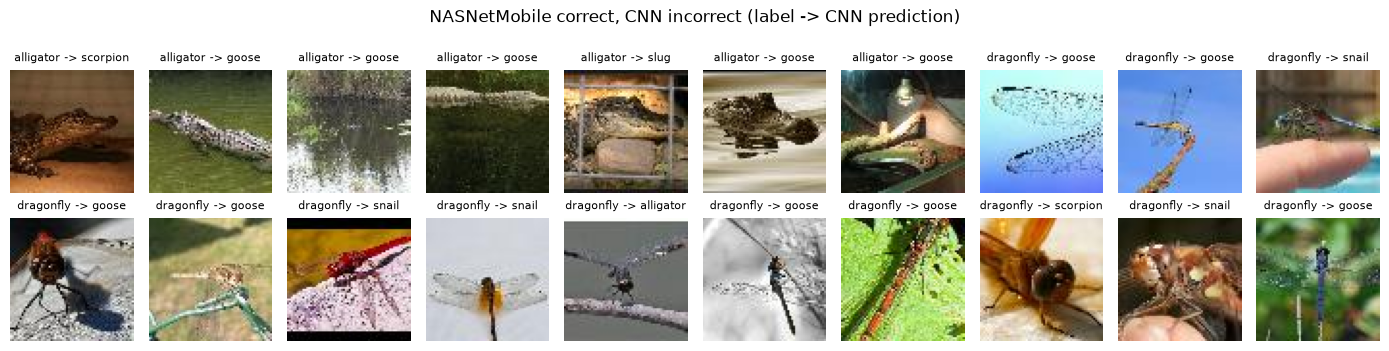

In [32]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["NASNetMobile correct, CNN incorrect"],
               y_pred=y_pred_cnn,
               title="NASNetMobile correct, CNN incorrect (label -> CNN prediction)")

The two models agree on most images, with 252 correct and 48 wrong for the same instances in the test set. On the 200 images where the 2 models disagree, NASNetMobile is usually the model that classifies correctly (177 correct vs 23 for CNN). As such, NASNetMobile isn't just more accurate overall, as when the 2 models disagree, NASNetMobile is usually the model that is correct. On closer inspection, you can also see that the 48 instances that both classes get wrong are the most difficult cases (second display_images()).

### Section 4.6: Summary and Conclusion

In this project we compared a small CNN trained from scratch against a frozen, pretrained NASNetMobile base model with only upper layers trained on a 10 class 3700 image dataset. We have already gone into detail for each comparison in previous subsections, so we will only provide a brief summary here.

**Results:** The CNN we trained from scratch with hyperparameter tuning reached 54.4% validation accuracy and with a closely matching 55.0% test accuracy. This indicates that that the model did not overfit nor underfit to the training data, and generalises well. The dropout layer and additional augmentation layer seems to have done their job well, but a 4-layer 8/32/32/32 filter network at 64 x 64 resolution simply can't resolve finer details. NASNetMobile in constrast shows mild overfitting (88% training vs 85% validation accuracy), which early stopping helped to keep in check. The errors most likely came from running out of new information in such a small fine-tuning set

**Model size:** NASNetMobile has ~3.5 times more trainable parameters than the CNN, but when we cound the frozen ImageNet base, the total parameter count exceeds 4.3 million. Nearly all of the extra size fromes from the parameters NASNetMobile already learned before this project, and directly contributions to its significantly higher performance compared to our small CNN model trained from scratch.

**Per class performance:** NASNetMobile performs better than our CNN on every single class, but not by the same amount everywhere. This is especially the case for more difficult classes like slug, snail and alligator. 

**Confusion matrices:** The same pattern as the per class performance shows up in the confusion matrices, where the CNN default predicts alligator for animals that look similar, resulting in the low precision seen above for alligator class recall. NASNetMobile in contrast is much closer to pure diagonal, with remaining confusion between slug and snail which are very hard classes to differentiate.

**Comparing predictions directly:** Looking at models side by side, both models get most of the instances correct or incorrect (300 out of 500), while for the remaining instances, NASNetMobile is generally correct while our CNN misclassifies.

**Conclusion:** with only 370 training instances per class, using a model that already has usedful image features learned from ImageNet is a far better choice than trying to train our own small CNN model through training. NASNetMobile's much larger parameter count brings higher accuracy and greater performance across classes while also training significantly faster. The CNN's 30 000 parameter budget is also a limiting factor on top of the already small training set. If the search space was allowed to go above this limit, we could have had a model with more layers or more filters per layer, however, this also risks overfitting on the small training set without strong regularisation. To reiterate, the best approach for a small dataset like tlhis is to adapt a pretrained model via transfer learning, as demonstrated in this project.